In [61]:
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
data = []

for _ in range(3000):

    sleep = random.randint(3, 10)
    stress = random.randint(1, 10)

    # Add slight randomness to inputs
    sleep = max(3, min(10, sleep + random.choice([-1, 0, 1])))
    stress = max(1, min(10, stress + random.choice([-1, 0, 1])))

    exercise = random.randint(0, 7)
    screen = random.randint(2, 14)
    work = random.randint(2, 12)
    water = random.randint(1, 5)

    # Calculate burnout score
    score = (
        (10 - sleep) * 2 +
        stress * 2 +
        screen +
        work -
        exercise * 2 -
        water
    )

    # Add noise
    score += random.randint(-5, 5)

    # Fuzzy boundaries
    if score < random.randint(16, 20):
        burnout = 0
    elif score < random.randint(26, 30):
        burnout = 1
    else:
        burnout = 2

    # Random label noise (5%)
    if random.random() < 0.05:
        burnout = random.choice([0, 1, 2])

    data.append([
        sleep,
        stress,
        exercise,
        screen,
        work,
        water,
        burnout
    ])

df = pd.DataFrame(
    data,
    columns=[
        "sleep",
        "stress",
        "exercise",
        "screen_time",
        "work_hours",
        "water",
        "burnout"
    ]
)

df.head()

,sleep,stress,exercise,screen_time,work_hours,water,burnout
0,10,8,7,7,7,2,0
1,5,10,6,9,2,2,1
2,9,1,2,14,6,5,0
3,4,8,6,9,12,3,2
4,10,10,5,12,5,2,1


In [63]:
df.describe()

,sleep,stress,exercise,screen_time,work_hours,water,burnout
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,6.467000,5.493000,3.530333,8.070000,6.976333,3.000333,1.049000
std,2.304781,2.867524,2.308865,3.754792,3.178544,1.430040,0.804248
min,3.000000,1.000000,0.000000,2.000000,2.000000,1.000000,0.000000
25%,4.000000,3.000000,1.000000,5.000000,4.000000,2.000000,0.000000
50%,7.000000,6.000000,4.000000,8.000000,7.000000,3.000000,1.000000
75%,8.000000,8.000000,6.000000,11.000000,10.000000,4.000000,2.000000
max,10.000000,10.000000,7.000000,14.000000,12.000000,5.000000,2.000000


In [64]:
df["burnout"].value_counts()

,count
burnout,
1,1053
2,1047
0,900


In [65]:
X = df.drop("burnout", axis=1)
y = df["burnout"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=42)

In [67]:
pred = model.predict(X_test)

In [68]:
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.7483333333333333


In [69]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.82      0.79      0.80       181
           1       0.64      0.73      0.68       211
           2       0.82      0.74      0.78       208

    accuracy                           0.75       600
   macro avg       0.76      0.75      0.75       600
weighted avg       0.76      0.75      0.75       600



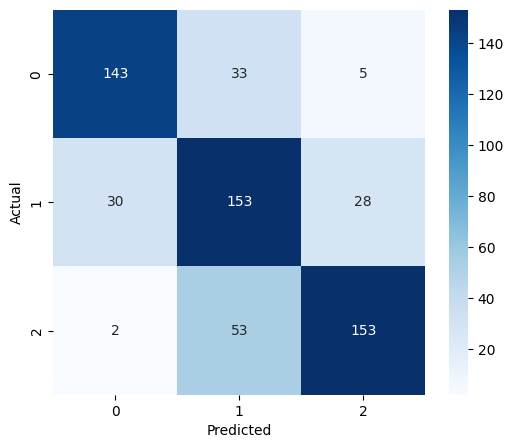

In [70]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

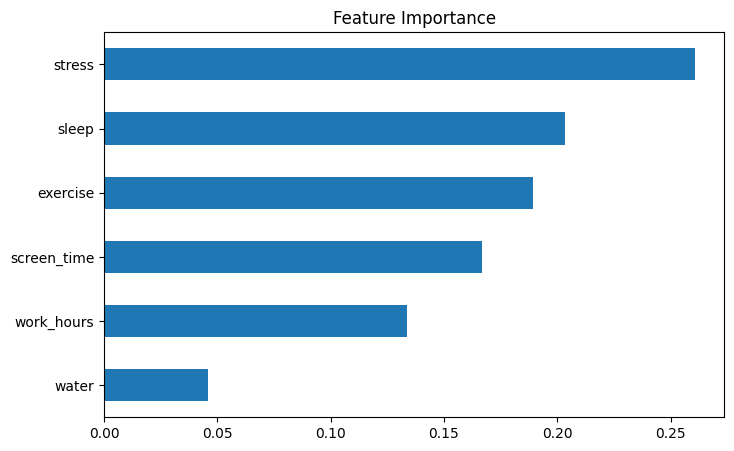

In [71]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

In [72]:
sleep = int(input("Sleep Hours: "))
stress = int(input("Stress Level (1-10): "))
exercise = int(input("Exercise Days: "))
screen = int(input("Screen Time: "))
work = int(input("Work Hours: "))
water = int(input("Water Intake: "))

user = pd.DataFrame([[
    sleep,
    stress,
    exercise,
    screen,
    work,
    water
]], columns=X.columns)

prediction = model.predict(user)[0]

# Get confidence
probabilities = model.predict_proba(user)[0]
confidence = max(probabilities) * 100

levels = {
    0: "Low",
    1: "Medium",
    2: "High"
}

emoji = {
    0: "🟢",
    1: "🟡",
    2: "🔴"
}

print(f"\n{emoji[prediction]} Burnout Risk: {levels[prediction]}")
print(f"Confidence: {confidence:.2f}%")

Sleep Hours: 5
Stress Level (1-10): 6
Exercise Days: 4
Screen Time: 8
Work Hours: 9
Water Intake: 5

🔴 Burnout Risk: High
Confidence: 58.77%


In [73]:
if prediction == 0:
    print("🌿 Keep maintaining your healthy habits!")

elif prediction == 1:
    print("😊 Moderate burnout risk detected.")
    print("- Take regular breaks")
    print("- Improve sleep schedule")
    print("- Stay hydrated")
    print("- Exercise more")

else:
    print("⚠️ High burnout risk detected!")
    print("- Increase sleep")
    print("- Reduce screen time")
    print("- Exercise regularly")
    print("- Take frequent breaks")
    print("- Maintain work-life balance")

# Explain factors
print("\nWhy?")

if sleep < 6:
    print("😴 Low sleep may increase burnout.")

if stress > 7:
    print("😰 High stress contributes significantly.")

if exercise < 2:
    print("🏃 Lack of exercise increases risk.")

if screen > 8:
    print("💻 Excessive screen time detected.")

if work > 9:
    print("🧑‍💻 Long working hours may cause burnout.")

⚠️ High burnout risk detected!
- Increase sleep
- Reduce screen time
- Exercise regularly
- Take frequent breaks
- Maintain work-life balance

Why?
😴 Low sleep may increase burnout.


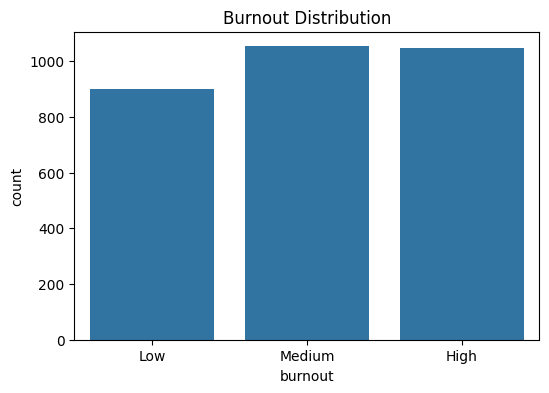

In [74]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["burnout"])

plt.xticks([0,1,2],["Low","Medium","High"])

plt.title("Burnout Distribution")

plt.savefig("burnout_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

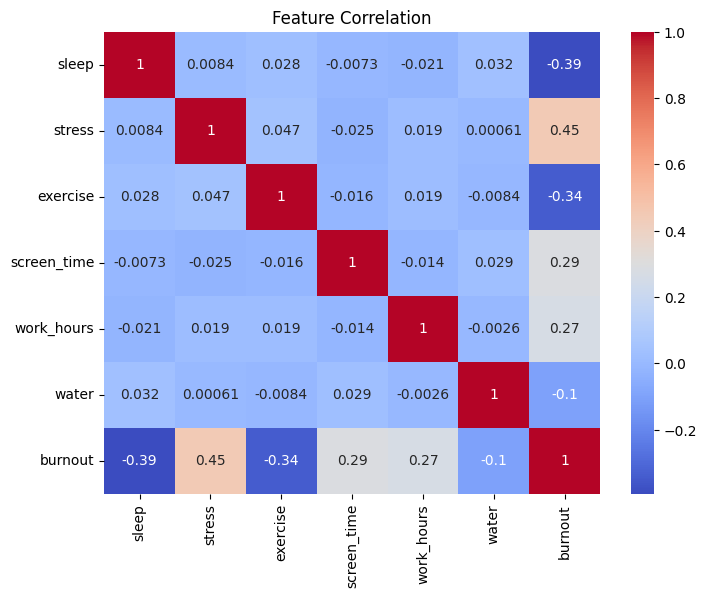

In [75]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [76]:
print("="*50)
print("🧠 MindPulse AI")
print("Burnout Risk Prediction System")
print("="*50)

🧠 MindPulse AI
Burnout Risk Prediction System


In [77]:
train_pred = model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, pred))

Train Accuracy: 0.8558333333333333
Test Accuracy: 0.7483333333333333


In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(max_depth=5)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

print("Logistic:", accuracy_score(y_test, lr.predict(X_test)))
print("Decision Tree:", accuracy_score(y_test, dt.predict(X_test)))
print("Random Forest:", accuracy_score(y_test, model.predict(X_test)))

Logistic: 0.7866666666666666
Decision Tree: 0.6483333333333333
Random Forest: 0.7483333333333333


In [79]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.76666667 0.725      0.75833333 0.76666667 0.71666667]
Average Accuracy: 0.7466666666666667
